In [1]:
import micro_sam
import skimage
import os
import matplotlib.pyplot as plt
import numpy as np

In [2]:
import torch
from typing import Optional, Union, Tuple
from micro_sam.evaluation.model_comparison import _enhance_image
from micro_sam.automatic_segmentation import get_predictor_and_segmenter, automatic_instance_segmentation

/scr/yren/miniconda3/envs/micronuclei-baselines/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
def run_automatic_instance_segmentation(
    image: np.ndarray,
    ndim: int,
    checkpoint_path: Optional[Union[os.PathLike, str]] = None,
    model_type: str = "vit_b_lm",
    device: Optional[Union[str, torch.device]] = None,
    tile_shape: Optional[Tuple[int, int]] = None,
    halo: Optional[Tuple[int, int]] = None,
):
    """Automatic Instance Segmentation (AIS) by training an additional instance decoder in SAM.

    NOTE: AIS is supported only for `µsam` models.

    Args:
        image: The input image.
        ndim: The number of dimensions for the input data.
        checkpoint_path: The path to stored checkpoints.
        model_type: The choice of the `µsam` model.
        device: The device to run the model inference.
        tile_shape: The tile shape for tiling-based segmentation.
        halo: The overlap shape on each side per tile for stitching the segmented tiles.

    Returns:
        The instance segmentation.
    """
    # Step 1: Get the 'predictor' and 'segmenter' to perform automatic instance segmentation.
    predictor, segmenter = get_predictor_and_segmenter(
        model_type=model_type,  # choice of the Segment Anything model
        checkpoint=checkpoint_path,  # overwrite to pass your own finetuned model.
        device=device,  # the device to run the model inference.
        amg=False,  # set the automatic segmentation mode to AIS.
        is_tiled=(tile_shape is not None),  # whether to run automatic segmentation with tiling.
    )

    # Step 2: Get the instance segmentation for the given image.
    prediction = automatic_instance_segmentation(
        predictor=predictor,  # the predictor for the Segment Anything model.
        segmenter=segmenter,  # the segmenter class responsible for generating predictions.
        input_path=image,  # the filepath to image or the input array for automatic segmentation.
        ndim=ndim,  # the number of input dimensions.
        tile_shape=tile_shape,  # the tile shape for tiling-based prediction.
        halo=halo,  # the overlap shape for tiling-based prediction.
    )

    return prediction


In [10]:
model_choice = 'vit_b_lm'
im = skimage.io.imread('/scr/yren/all_data_micronuclei/validation/20X_c0-DAPI_A1_Tile-50.phenotype.tif')
im = ((im / im.max()) * 255).astype(np.uint8)
prediction = run_automatic_instance_segmentation(im, ndim=2, model_type=model_choice, device='cuda', tile_shape=(1024, 1024), halo=(256, 256))

Compute Image Embeddings 2D tiled: 100%|██████████| 9/9 [00:02<00:00,  3.78it/s]
Initialize tiled instance segmentation with decoder: 100%|██████████| 9/9 [00:00<00:00, 17.50it/s]


(2960, 2960)


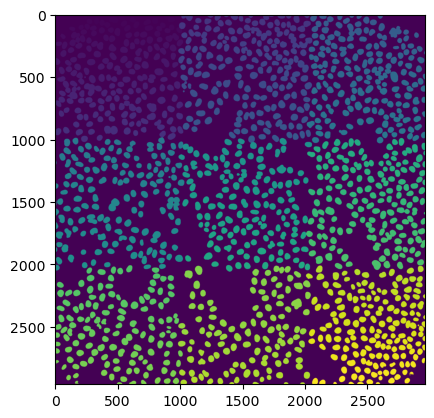

In [6]:
print(prediction.shape)
plt.imshow(prediction)